# Two-logical-qubit universal PEC: $C_1 \rightarrow \mathrm{CX} \rightarrow C_2 \rightarrow T\otimes T$


Each macro layer is
$
(C^{(1)}_c\otimes C^{(1)}_t)
\rightarrow \overline{\mathrm{CX}}_{c\to t}
\rightarrow (C^{(2)}_c\otimes C^{(2)}_t)
\rightarrow (T_c\otimes T_t).
$

The `C1 + CX` block is mitigated with the effective dressed-CX inverse learned by CX-CSB. The second local Clifford layer uses the shared single-qubit Clifford model, and each injected $T$ gate uses the phase-covariant $T$-cycle model. Twirls and sampled PEC Paulis are compiled into existing logical Clifford or injection-correction slots by `logical_csb.py`.

In [1]:
from importlib import reload
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import logical_csb as lc
reload(lc)

# Shared execution settings
N_JOBS = 20
BASE_SEED = 1234

MIN_EC_ROUNDS = 2
MAX_EC_ROUNDS = 4
DECODER_CACHE = Path("steane_flag_decoder_stabilizer_max4.pkl")

CIRCUIT_OPTIONS = {
    "prep_gates_noisy": True,
    "prep_qec_after_gate": True,
    "measurement_basis_gates_noisy": True,
    "qec_after_each_logical_gate": True,
    "fallback_on_unverified": True,
}

TWO_QUBIT_FACTOR = 2.0
FINAL_MEAS_FACTOR = 1.0

# Numerical data are never written to disk.
SAVE_FIGURES = True
FIGURE_DIR = Path(".")

decoder = lc.get_or_build_decoder(
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=False,
)

def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
    )

def save_pdf(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / filename,
            bbox_inches="tight",
        )

## 1. Noise model

In [2]:
PHYSICAL_STRENGTH = 3.0e-4

# Accepted magic-state error
MAGIC_ANGLE_ERROR = 0.01
MAGIC_ERROR_RATE = 1.0e-4
MAGIC_NU = {
    "X": 1.0 / 3.0,
    "Y": 1.0 / 3.0,
    "Z": 1.0 / 3.0,
}

T_PHASE_TWIRL = True
CX_PHASE_TWIRL = True

UNIVERSAL_MODEL = lc.make_universal_noise_model(
    physical_strength=PHYSICAL_STRENGTH,
    two_qubit_factor=TWO_QUBIT_FACTOR,
    final_meas_factor=FINAL_MEAS_FACTOR,
    magic_angle_error=MAGIC_ANGLE_ERROR,
    magic_error_rate=MAGIC_ERROR_RATE,
    magic_nu=MAGIC_NU,
    t_phase_twirl=T_PHASE_TWIRL,
    cx_phase_twirl=CX_PHASE_TWIRL,
)

## 2. Learning and universal-circuit settings

In [7]:
# Injected-T CSB
T_STEPS = list(range(13))
T_REP = 9
T_SHOTS = 1000
T_CHUNK_SHOTS = 100

# Shared one-qubit Clifford CSB
CLIFFORD_STEPS = list(range(13))
CLIFFORD_REP = 9
CLIFFORD_SHOTS = 1000
CLIFFORD_CHUNK_SHOTS = 100

# Predressed, phase-twirled logical-CX CSB
CX_STEPS = list(range(13))
CX_REP = 9
CX_SHOTS = 1000
CX_CHUNK_SHOTS = 100

# Universal C1-CX-C2-(T x T) validation
UNIVERSAL_DEPTHS = [ 2, 4, 6, 8, 12]
SEQUENCES_PER_DEPTH = 20
NOISY_SHOTS_PER_SEQUENCE = 10000
PEC_SHOTS_PER_SEQUENCE = 100000

# Complete independent learning + validation workflows.
# Reported error bars are sample standard deviations across these workflows.
N_COMPLETE_REPEATS = 10
SEED_STRIDE = 10_000_019

## 3. Complete CSB-learning and universal-PEC workflow

For each repeat, the $T$, one-qubit Clifford, and dressed-CX effective channels are learned independently from CSB. Their inverse quasiprobability models are then applied to the same set of random universal circuits. 

In [8]:
def sample_std(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.std(values, ddof=1)) if len(values) > 1 else 0.0


t_rows = []
clifford_rows = []
cx_rows = []
pec_rows = []

for repeat_id in range(N_COMPLETE_REPEATS):
    seed = int(BASE_SEED + repeat_id * SEED_STRIDE)

    # --------------------------------------------------------
    # T-cycle learning
    # --------------------------------------------------------
    t_csb = lc.run_t_csb_spectrum(
        decoder=decoder,
        model=UNIVERSAL_MODEL.t_model(),
        options=CIRCUIT_OPTIONS,
        steps=T_STEPS,
        rep=T_REP,
        shots=T_SHOTS,
        seed=seed + 100_003,
        n_jobs=N_JOBS,
        chunk_shots=T_CHUNK_SHOTS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )
    t_learning = lc.fit_t_csb_spectra(t_csb)

    t_row = t_learning["summary_df"].iloc[0].to_dict()
    t_row["repeat_id"] = repeat_id
    t_rows.append(t_row)

    # --------------------------------------------------------
    # Shared one-qubit Clifford learning
    # --------------------------------------------------------
    clifford_learning = lc.learn_clifford_pauli_model(
        decoder=decoder,
        noise=UNIVERSAL_MODEL.physical_noise,
        options=CIRCUIT_OPTIONS,
        steps=CLIFFORD_STEPS,
        rep=CLIFFORD_REP,
        shots=CLIFFORD_SHOTS,
        chunk_shots=CLIFFORD_CHUNK_SHOTS,
        seed=seed + 200_003,
        n_jobs=N_JOBS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )

    c_row = clifford_learning["pauli_df"].iloc[0].to_dict()
    c_row["repeat_id"] = repeat_id
    clifford_rows.append(c_row)

    # --------------------------------------------------------
    # Predressed logical-CX learning
    # --------------------------------------------------------
    cx_csb = lc.run_cx_csb_spectrum(
        decoder=decoder,
        noise=UNIVERSAL_MODEL.physical_noise,
        options=CIRCUIT_OPTIONS,
        steps=CX_STEPS,
        rep=CX_REP,
        shots=CX_SHOTS,
        seed=seed + 300_007,
        n_jobs=N_JOBS,
        chunk_shots=CX_CHUNK_SHOTS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )
    cx_learning = lc.learning_tables_from_cx_csb(
        cx_csb,
        beta=None,
    )

    cx_repeat = cx_learning["tau_df"][
        ["pauli", "probability_projected", "inverse_q"]
    ].copy()
    cx_repeat["repeat_id"] = repeat_id
    cx_rows.append(cx_repeat)

    # --------------------------------------------------------
    # Universal PEC validation
    # --------------------------------------------------------
    validation = lc.run_universal_pec_validation(
    decoder=decoder,
    model=UNIVERSAL_MODEL,
    options=CIRCUIT_OPTIONS,
    clifford_inverse_q=clifford_learning["inverse_q"],
    dressed_cx_inverse_q=cx_learning["tau_inverse_q"],
    t_inverse_q=t_learning["inverse_q"],
    depths=UNIVERSAL_DEPTHS,
    sequences_per_depth=SEQUENCES_PER_DEPTH,
    noisy_shots=NOISY_SHOTS_PER_SEQUENCE,
    pec_shots=PEC_SHOTS_PER_SEQUENCE,
    circuit_seed=seed + 600_001,
    sampling_seed=seed + 700_001,
    n_jobs=N_JOBS,
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=False,
    )

    p = validation["summary_df"].copy()
    p["repeat_id"] = repeat_id
    pec_rows.append(p)


T_REPEATS_DF = pd.DataFrame(t_rows)
CLIFFORD_REPEATS_DF = pd.DataFrame(clifford_rows)
CX_REPEATS_DF = pd.concat(cx_rows, ignore_index=True)
PEC_REPEATS_DF = pd.concat(pec_rows, ignore_index=True)


# ------------------------------------------------------------
# Repeat-level summaries
# ------------------------------------------------------------

T_REPEATS_DF["abs_delta_theta"] = np.abs(
    T_REPEATS_DF["delta_theta"].to_numpy(float)
)

t_summary = {}
for col in [
    "g", "f", "abs_delta_theta", "process_infidelity",
    "p_I", "p_X", "p_Y", "p_Z", "gamma_per_cycle",
]:
    values = T_REPEATS_DF[col].to_numpy(float)
    t_summary[f"{col}_mean"] = float(np.mean(values))
    t_summary[f"{col}_std"] = sample_std(values)
T_SUMMARY_DF = pd.DataFrame([t_summary])


c_summary = {}
for col in ["p_I", "p_X", "p_Y", "p_Z", "gamma_per_cycle"]:
    values = CLIFFORD_REPEATS_DF[col].to_numpy(float)
    c_summary[f"{col}_mean"] = float(np.mean(values))
    c_summary[f"{col}_std"] = sample_std(values)
CLIFFORD_SUMMARY_DF = pd.DataFrame([c_summary])


cx_summary_rows = []
for pauli, sub in CX_REPEATS_DF.groupby("pauli", sort=True):
    cx_summary_rows.append({
        "pauli": pauli,
        "probability_mean": float(np.mean(sub["probability_projected"])),
        "probability_std": sample_std(sub["probability_projected"]),
        "inverse_q_mean": float(np.mean(sub["inverse_q"])),
        "inverse_q_std": sample_std(sub["inverse_q"]),
    })
CX_SUMMARY_DF = pd.DataFrame(cx_summary_rows)


pec_summary_rows = []
for depth, sub in PEC_REPEATS_DF.groupby("depth", sort=True):
    row = {
        "depth": int(depth),
        "n_repeats": int(sub["repeat_id"].nunique()),
    }
    for source, output in [
        ("noisy_tv_mean", "noisy_tv"),
        ("pec_tv_mean", "pec_tv"),
        ("noisy_map_error_mean", "noisy_map_error"),
        ("pec_map_error_mean", "pec_map_error"),
        ("pec_mean_abs_weight", "pec_mean_abs_weight"),
        ("pec_gamma_per_macro_layer", "gamma_per_macro_layer"),
    ]:
        values = sub[source].to_numpy(float)
        row[f"{output}_mean"] = float(np.mean(values))
        row[f"{output}_std"] = sample_std(values)
    pec_summary_rows.append(row)

PEC_SUMMARY_DF = pd.DataFrame(pec_summary_rows).sort_values(
    "depth"
).reset_index(drop=True)

# Compact numerical output only.
display(
    PEC_SUMMARY_DF[
        ["depth", "noisy_tv_mean", "noisy_tv_std", "pec_tv_mean", "pec_tv_std"]
    ]
)

,depth,noisy_tv_mean,noisy_tv_std,pec_tv_mean,pec_tv_std
0,2,0.023917,0.002579,0.002389,0.000184
1,4,0.047903,0.002730,0.003093,0.000221
2,6,0.069338,0.002971,0.003941,0.000426
3,8,0.089044,0.008187,0.004631,0.000616
4,12,0.123732,0.007534,0.006840,0.000473


## 4. Learned logical Pauli models

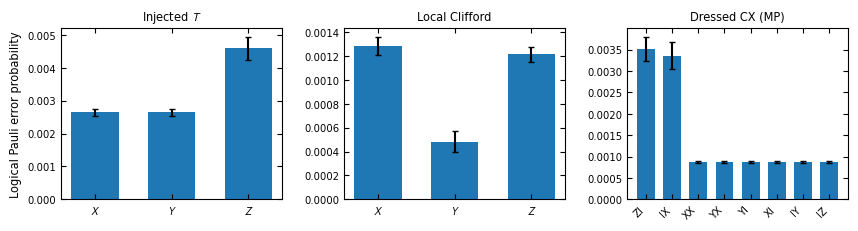

In [5]:
with mpl.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "axes.titlesize": 8.2,
    "legend.fontsize": 6.2,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(8.6, 2.55),
    )

    labels_1q = ["X", "Y", "Z"]
    xpos = np.arange(3)

    # (a) Injected T
    t_mean = np.array([
        T_SUMMARY_DF[f"p_{p}_mean"].iloc[0]
        for p in labels_1q
    ])
    t_std = np.array([
        T_SUMMARY_DF[f"p_{p}_std"].iloc[0]
        for p in labels_1q
    ])
    axes[0].bar(
        xpos,
        t_mean,
        yerr=t_std,
        capsize=2.0,
        width=0.62,
    )
    axes[0].set_xticks(xpos, [rf"${p}$" for p in labels_1q])
    axes[0].set_ylabel("Logical Pauli error probability")
    axes[0].set_title(r"Injected $T$")

    # (b) Shared local Clifford channel
    c_mean = np.array([
        CLIFFORD_SUMMARY_DF[f"p_{p}_mean"].iloc[0]
        for p in labels_1q
    ])
    c_std = np.array([
        CLIFFORD_SUMMARY_DF[f"p_{p}_std"].iloc[0]
        for p in labels_1q
    ])
    axes[1].bar(
        xpos,
        c_mean,
        yerr=c_std,
        capsize=2.0,
        width=0.62,
    )
    axes[1].set_xticks(xpos, [rf"${p}$" for p in labels_1q])
    axes[1].set_title("Local Clifford")

    # (c) Moore-Penrose dressed-CX representative
    cx_nonidentity = (
        CX_SUMMARY_DF[CX_SUMMARY_DF["pauli"] != "II"]
        .sort_values("probability_mean", ascending=False)
        .head(8)
        .reset_index(drop=True)
    )
    xcx = np.arange(len(cx_nonidentity))
    axes[2].bar(
        xcx,
        cx_nonidentity["probability_mean"].to_numpy(float),
        yerr=cx_nonidentity["probability_std"].to_numpy(float),
        capsize=2.0,
        width=0.68,
    )
    axes[2].set_xticks(
        xcx,
        cx_nonidentity["pauli"].tolist(),
        rotation=45,
        ha="right",
    )
    axes[2].set_title("Dressed CX (MP)")

    for ax in axes:
        format_axis(ax)

    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        bottom=0.23,
        top=0.90,
        wspace=0.28,
    )

    # save_pdf(
    #     fig,
    #     "fig_universal_learned_pauli_models.pdf",
    # )
    plt.show()

## 5. Universal-circuit PEC validation

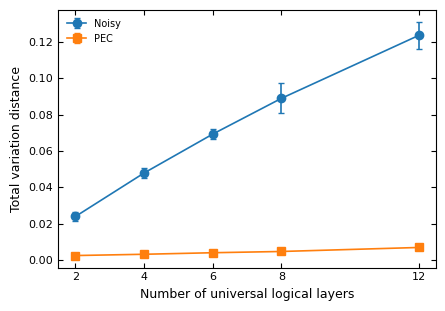

In [10]:
depth = PEC_SUMMARY_DF["depth"].to_numpy(float)

with mpl.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}):
    fig, ax = plt.subplots(
        figsize=(4.5, 3.15),
    )

    ax.errorbar(
        depth,
        PEC_SUMMARY_DF["noisy_tv_mean"],
        yerr=PEC_SUMMARY_DF["noisy_tv_std"],
        marker="o",
        linestyle="-",
        capsize=2.2,
        label="Noisy",
    )

    ax.errorbar(
        depth,
        PEC_SUMMARY_DF["pec_tv_mean"],
        yerr=PEC_SUMMARY_DF["pec_tv_std"],
        marker="s",
        linestyle="-",
        capsize=2.2,
        label="PEC",
    )

    ax.set_xticks(depth.astype(int))
    ax.set_xlabel(r"Number of universal logical layers")
    ax.set_ylabel("Total variation distance")

    format_axis(ax)
    ax.legend(
        loc="upper left",
        frameon=False,
    )

    fig.tight_layout()

    save_pdf(
        fig,
        "universal_pec_validation.pdf",
    )
    plt.show()

In [11]:
# ============================================================
# Unified paper figure style
# ============================================================

SINGLE_COLUMN_WIDTH = 3.45

PAPER_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "mathtext.fontset": "stixsans",

    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "axes.titlesize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 6.4,

    "axes.linewidth": 0.8,
    "lines.linewidth": 1.1,
    "lines.markersize": 4.0,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}


def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        width=0.8,
        length=3.0,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        length=1.8,
    )


def panel_label(ax, text):
    ax.text(
        -0.16,
        1.035,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )

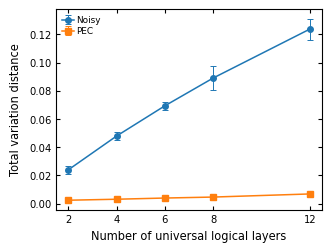

In [12]:
depth = PEC_SUMMARY_DF[
    "depth"
].to_numpy(float)

with mpl.rc_context(PAPER_RC):

    fig, ax = plt.subplots(
        figsize=(SINGLE_COLUMN_WIDTH, 2.55),
    )

    ax.errorbar(
        depth,
        PEC_SUMMARY_DF["noisy_tv_mean"],
        yerr=PEC_SUMMARY_DF["noisy_tv_std"],
        marker="o",
        linestyle="-",
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.7,
        label="Noisy",
    )

    ax.errorbar(
        depth,
        PEC_SUMMARY_DF["pec_tv_mean"],
        yerr=PEC_SUMMARY_DF["pec_tv_std"],
        marker="s",
        linestyle="-",
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.7,
        label="PEC",
    )

    ax.set_xticks(
        depth.astype(int)
    )

    ax.set_xlabel(
        "Number of universal logical layers",
        labelpad=4,
    )

    ax.set_ylabel(
        "Total variation distance",
        labelpad=5,
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.30,
        labelspacing=0.25,
    )

    format_axis(ax)

    fig.subplots_adjust(
        left=0.215,
        right=0.985,
        bottom=0.19,
        top=0.975,
    )

    fig.savefig(
        "universal_pec_validation.pdf",
        bbox_inches="tight",
        pad_inches=0.03,
    )

    plt.show()